# Multi-modal RAG using FAISS

you will need either `brew install poppler` to run this notebook

### imports

In [4]:
import requests
import os
from pdf2image import convert_from_path
from transformers import AutoProcessor, AutoTokenizer, AutoModelForZeroShotImageClassification, AutoModelForImageTextToText
import faiss
from datasets import Dataset, Image
from collections import defaultdict
import matplotlib.pyplot as plt
import torch
import torch.nn
import PIL
import torchvision.transforms as T
from utils import convert_pdfs_to_images, plot_images, create_hf_dataset, add_img_embedding_column, add_txt_embedding_column, retrieve_images_by_prompt, unnormalize_image
from attack import adversarial_attack_fgsm_iterative

### Functions

### Download IKEA PDFs

In [5]:
pdfs = {
    "MALM": "https://www.ikea.com/us/en/assembly_instructions/malm-4-drawer-chest-white__AA-2398381-2-100.pdf",
    "BILLY": "https://www.ikea.com/us/en/assembly_instructions/billy-bookcase-white__AA-1844854-6-2.pdf",
    "BOAXEL": "https://www.ikea.com/us/en/assembly_instructions/boaxel-wall-upright-white__AA-2341341-2-100.pdf",
    "ADILS": "https://www.ikea.com/us/en/assembly_instructions/adils-leg-white__AA-844478-6-2.pdf",
    "MICKE": "https://www.ikea.com/us/en/assembly_instructions/micke-desk-white__AA-476626-10-100.pdf",
}

data_dir = "../../data/ikea"
os.makedirs(data_dir, exist_ok=True)

for name, url in pdfs.items():
    response = requests.get(url)
    pdf_path = os.path.join(data_dir, f"{name}.pdf")

    with open(pdf_path, "wb") as f:
        f.write(response.content)

    print(f"Downloaded {name} to {pdf_path}")

print("Downloaded files:", os.listdir(data_dir))

Downloaded MALM to ../../data/ikea/MALM.pdf
Downloaded BILLY to ../../data/ikea/BILLY.pdf
Downloaded BOAXEL to ../../data/ikea/BOAXEL.pdf
Downloaded ADILS to ../../data/ikea/ADILS.pdf
Downloaded MICKE to ../../data/ikea/MICKE.pdf
Downloaded files: ['MICKE.pdf', 'BOAXEL.pdf', 'ADILS.pdf', 'MALM.pdf', 'BILLY.pdf']


### Convert each PDF page to an Image 

['MICKE.pdf', 'BOAXEL.pdf', 'ADILS.pdf', 'MALM.pdf', 'BILLY.pdf']
[24, 20, 8, 28, 16]


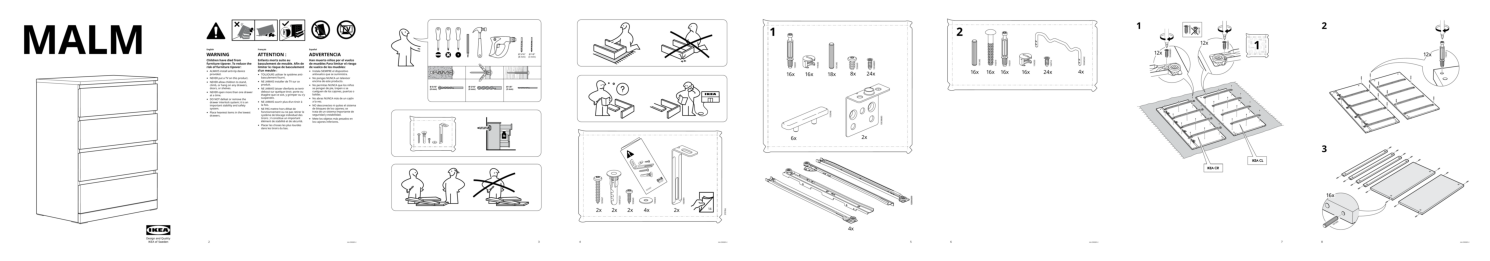

In [6]:
all_images = convert_pdfs_to_images(data_dir)
print([len(pdf) for pdf in all_images.values()])
plot_images(all_images[3], n_subplots=8)

### create a HF Dataset

In [7]:
ds = create_hf_dataset(all_images)
len(ds)

96

### Load Embedding Model

In [8]:
model_name = "openai/clip-vit-base-patch16" # "openai/clip-vit-base-patch16", "nomic-ai/nomic-embed-vision-v1.5", "jinaai/jina-clip-v2" (large), "jinaai/jina-clip-v1"

processor = AutoProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForZeroShotImageClassification.from_pretrained(model_name)
# processor.image_processor.do_center_crop = False

### Create Embeddings and FAISS Retriever 

In [9]:
ds_with_embeddings = add_img_embedding_column(ds, model, processor, existing_col_name="image", new_col_name="image_embeddings")
ds_with_embeddings.add_faiss_index(column="image_embeddings")

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['file', 'page', 'image', 'image_embeddings'],
    num_rows: 96
})

### Test Retrieval

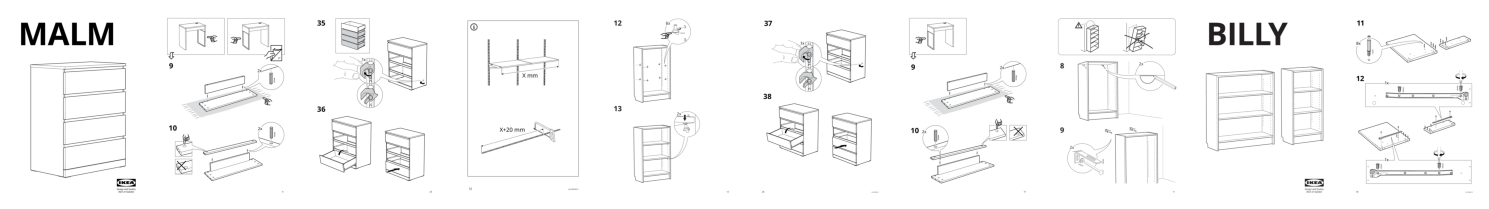

(array([124.16735, 136.1488 , 136.91074, 138.18219, 138.3454 , 138.73148,
        139.19637, 139.28435, 139.75215, 139.86453], dtype=float32),
 [3, 0, 3, 1, 4, 3, 0, 4, 4, 0])

In [10]:
prompt = "How does the MALM look like?"
topk = 10

scores, retrieved = retrieve_images_by_prompt(prompt, ds_with_embeddings, model, tokenizer, topk)
scores, retrieved['file']

### Create Adversarial example

In [11]:
# index 24 corresponds to first page of BOAXEL (irrelevant to query), index 52 corresponds to the correct photo (MALM)
irrelevant_image = ds_with_embeddings[24]["image"]
image_input = processor(images=[irrelevant_image], return_tensors='pt')
# store the initial image before perturbation
initial_image = image_input['pixel_values'].clone()

In [12]:
lr = 5e-3
n_iters = 50
perturb_max = 0.05

image_adv = adversarial_attack_fgsm_iterative(image_input, model, prompt, tokenizer, processor, n_iters, lr, initial_image, perturb_max)
print(f"perturbation MSE : {torch.nn.functional.mse_loss(image_adv['pixel_values'], initial_image)}")

0 0.2974138557910919
10 0.2136305868625641
20 0.18911457061767578
30 0.17830431461334229
40 0.19819152355194092
perturbation MSE : 0.0008036480285227299


In [13]:
image_adv['pixel_values'].min(), image_adv['pixel_values'].max(), initial_image.min(), initial_image.max()

(tensor(-1.7923, grad_fn=<MinBackward1>),
 tensor(2.1459, grad_fn=<MaxBackward1>),
 tensor(-1.7923),
 tensor(2.1459))

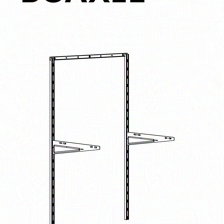

In [15]:
# convert image tensor to PIL image
transform = T.ToPILImage()
image = transform(unnormalize_image(image_input['pixel_values'][0], processor))
image

### Create a new Dataset with the adverarial Image

In [16]:
# add a new dict entry for the adversarial image
all_images[100]=[image]
# create a new dataset
ds_adv = create_hf_dataset(all_images)
ds_adv_with_embeddings = add_img_embedding_column(ds_adv, model, processor, existing_col_name="image", new_col_name="image_embeddings")
ds_adv_with_embeddings.add_faiss_index(column="image_embeddings") 

Map:   0%|          | 0/97 [00:00<?, ? examples/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Dataset({
    features: ['file', 'page', 'image', 'image_embeddings'],
    num_rows: 97
})

### Test Retrieval with the Corrupted Dataset

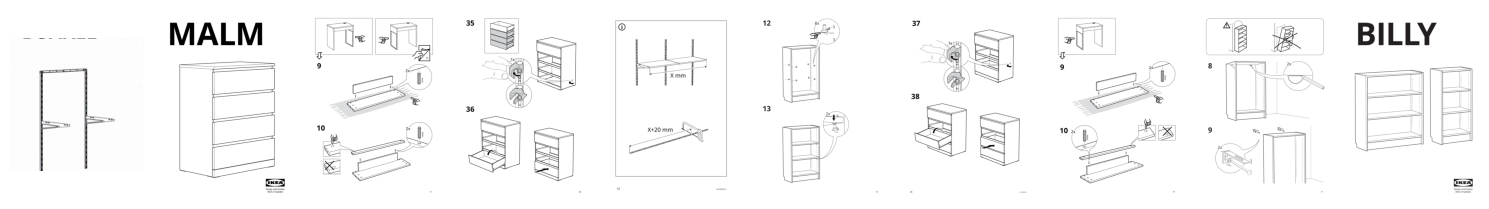

(array([ 96.14096, 124.16735, 136.1488 , 136.91074, 138.18219, 138.3454 ,
        138.73148, 139.19637, 139.28435, 139.75215], dtype=float32),
 [100, 3, 0, 3, 1, 4, 3, 0, 4, 4])

In [17]:
topk=10
scores, retrieved = retrieve_images_by_prompt(prompt, ds_adv_with_embeddings, model, tokenizer, topk)
scores, retrieved["file"]